# Data characterisation — methods section

Three parts:

1. **Spectral analysis across all six damage categories** — how the optical signal
   changes as severity increases, and whether Planet imagery already shows July damage
   on footprints that are still labelled intact in May.

2. **Spatial clustering and data-leakage risk** — KNN-based local damage rate as a
   spatial smoother, then a direct comparison of random vs latitude-quantile splits to
   quantify how much cross-split contamination each approach produces.

3. **Systematic split comparison** — structural differences between train / stack / val /
   test under the binary labelling rule (UNOSAT classes 1–3 = damaged, 4 and 11 = intact).

**Damage categories** (ordered by expected severity, excluding class 6 and NaN):

| Key | UNOSAT | Assessment | Binary label |
|---|---|---|---|
| `c11` | No visible damage | May 2024 | 0 intact |
| `c4`  | Possibly damaged   | May 2024 | 0 intact (class 4 excluded) |
| `c3`  | Moderately damaged | May 2024 | 1 damaged |
| `c2`  | Severely damaged   | May 2024 | 1 damaged |
| `c1`  | Destroyed          | May 2024 | 1 damaged |
| `new_part` | Newly damaged between May and July 2024 (from `c11`/`c4`) | May→Jul 2024 | 1 damaged |


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q rasterio geopandas scikit-learn scipy

In [5]:
import os, glob
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

PROJECT_ROOT = Path('/content/drive/MyDrive/War-Damage-Detection')
PROJECT_DIR  = PROJECT_ROOT / 'planet' / 'data' / 'processed'
UNOSAT_DIR   = PROJECT_ROOT / 'shared' / 'data' / 'unosat'

# UNOSAT assessment used for the July comparison.
JUL_GDB = str(UNOSAT_DIR / 'UNOSAT_GazaStrip_CDA_06July2024.gdb')

BANDS = ['B', 'G', 'R', 'NIR']
PRE   = [0, 1, 2, 3]
POST  = [4, 5, 6, 7]

SAR_BANDS    = ['VV', 'VH']
SAR_PRE_IDX  = [8, 9]
SAR_POST_IDX = [10, 11]

# Patch footprints on the ground, used later for the data-leakage analysis.
PATCH_M_PLANET = 32 * 3    # 96 m  — PlanetScope patch (32 px @ 3 m/px)
PATCH_M_SAR    = 32 * 10   # 320 m — Sentinel-1 SAR patch (32 px @ 10 m/px)

# load NPZ + parquet
files = sorted(glob.glob(str(PROJECT_DIR / 'Gaza_*.npz')))
assert files, f'No .npz in {PROJECT_DIR}/'
z = np.load(files[-1], allow_pickle=False)
X        = z['X'].astype('float32')          # Planet-only (8 channels) until SAR is fused below
y_binary = z['y'].astype(int)

parquet_path = files[-1].replace('.npz', '.parquet')
table = gpd.read_parquet(parquet_path).reset_index(drop=True)

if 'lon' not in table.columns or 'lat' not in table.columns:
    centroids = table.geometry.centroid
    table['lon'] = centroids.x
    table['lat'] = centroids.y
if 'area' not in table.columns:
    table['area'] = table.to_crs('EPSG:32636').geometry.area

print(f'Loaded {os.path.basename(files[-1])}')
print(f'X: {X.shape}  y: {y_binary.shape}  table: {len(table):,} rows')
print(f'Prevalence (1–3 rule): {100*y_binary.mean():.1f}%')

Loaded Gaza_20240503_320a78e597.npz
X: (188874, 8, 32, 32)  y: (188874,)  table: 188,874 rows
Prevalence (1–3 rule): 53.8%


## 0 · Assign damage categories

Join the May and July 2024 UNOSAT assessments to each footprint via a 100 m
nearest-neighbour spatial join. Footprints with no May match are excluded;
footprints rated "no visible damage" or "possibly damaged" in May but
"moderate/severe/destroyed" in July are relabelled `new_part`.

In [6]:
print('Joining UNOSAT labels — May 2024 vs July 2024')

if table.crs is None or table.crs.to_epsg() != 32636:
    table_utm = table.set_crs('EPSG:4326', allow_override=True).to_crs('EPSG:32636')
else:
    table_utm = table.copy()

MAY_GDB = str(UNOSAT_DIR / 'UNOSAT_GazaStrip_CDA_03May2024_v2.gdb')
JUL_GDB = str(UNOSAT_DIR / 'UNOSAT_GazaStrip_CDA_06July2024.gdb')

may = gpd.read_file(MAY_GDB, layer='Damage_Sites_GazaStrip_20240503_v2',
                     columns=['geometry', 'Main_Damage_Site_Class_7'])
jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20240706',
                     columns=['geometry', 'Main_Damage_Site_Class_7'])

may_utm = may.to_crs('EPSG:4326').to_crs('EPSG:32636')
jul_utm = jul.to_crs('EPSG:4326').to_crs('EPSG:32636')

base = table_utm[['geometry']].assign(idx=np.arange(len(table)))

joined_may = gpd.sjoin_nearest(base, may_utm[['geometry', 'Main_Damage_Site_Class_7']],
                                how='left', max_distance=100
                     ).drop_duplicates('idx').set_index('idx').sort_index()
joined_jul = gpd.sjoin_nearest(base, jul_utm[['geometry', 'Main_Damage_Site_Class_7']],
                                how='left', max_distance=100
                     ).drop_duplicates('idx').set_index('idx').sort_index()

cls_may = joined_may['Main_Damage_Site_Class_7']
cls_jul = joined_jul['Main_Damage_Site_Class_7']

FULLY = {1, 2}; PARTLY = {3, 4}
def grp(c):
    if pd.isna(c): return 'none'
    c = int(c); return 'fully' if c in FULLY else ('partly' if c in PARTLY else 'none')

grp_jul = cls_jul.map(grp).fillna('none')

def assign7(i):
    cm = cls_may.get(i, np.nan)
    cj = cls_jul.get(i, np.nan)

    if pd.isna(cm):
        return None  # no May annotation — no baseline to compare against

    cm = int(cm)

    if cm in (11, 4):
        if not pd.isna(cj) and int(cj) in (1, 2, 3):
            return 'new_part'   # intact/possible in May, damaged by July
        return 'c11' if cm == 11 else 'c4'

    return {3: 'c3', 2: 'c2', 1: 'c1'}.get(cm)  # class 6 / other -> None

cat7 = np.array([assign7(i) for i in range(len(X))], dtype=object)

CAT_META = {
    'c11':      dict(label='11 — No visible damage',             color='#6C757D', binary=0),
    'c4':       dict(label='4 — Possibly damaged',                color='#ADB5BD', binary=0),
    'c3':       dict(label='3 — Moderately damaged',              color='#FFC107', binary=1),
    'c2':       dict(label='2 — Severely damaged',                color='#E67E22', binary=1),
    'c1':       dict(label='1 — Destroyed',                       color='#E74C3C', binary=1),
    'new_part': dict(label='Jul24 — newly damaged (from 11/4)',   color='#27AE60', binary=1),
}
ORDER = ['c11', 'c4', 'c3', 'c2', 'c1', 'new_part']

print('Category distribution:')
for k in ORDER:
    m = CAT_META[k]; n = (cat7 == k).sum()
    print(f'  {m["label"]:36s} {n:>8,}  binary={m["binary"]}')
print(f'  {"unmatched / class 6":36s} {(cat7==None).sum():>8,}')

Joining UNOSAT labels — May 2024 vs July 2024
Category distribution:
  11 — No visible damage                 10,593  binary=0
  4 — Possibly damaged                   41,561  binary=0
  3 — Moderately damaged                 57,812  binary=1
  2 — Severely damaged                   17,644  binary=1
  1 — Destroyed                          34,093  binary=1
  Jul24 — newly damaged (from 11/4)       2,641  binary=1
  unmatched / class 6                    24,530


## 0b · Fuse Sentinel-1 SAR into the patch tensor

The Planet extraction pipeline stores optical bands only. SAR pre/post VV/VH
patches are extracted separately at footprint level; each row is matched to
its nearest SAR building centroid and appended as channels 8–11.

In [7]:
SAR_DIR = PROJECT_ROOT / 'sentinel_sar' / 'data' / 'processed'

sar_buildings = gpd.read_parquet(SAR_DIR / 'gaza_p32_footprints_lbl1-2-3_nNone_s1_buildings.parquet')

sar_pre_X     = np.load(SAR_DIR / 'gaza_p32_footprints_lbl1-2-3_nNone_s1_pre12m_native_X.npy', mmap_mode='r')
sar_pre_valid = np.load(SAR_DIR / 'gaza_p32_footprints_lbl1-2-3_nNone_s1_pre12m_native_valid.npy')

sar_post_X     = np.load(SAR_DIR / 'gaza_20240503_p32_footprints_lbl1-2-3_nNone_s1_post_nearest1_fb0_native_X.npy', mmap_mode='r')
sar_post_valid = np.load(SAR_DIR / 'gaza_20240503_p32_footprints_lbl1-2-3_nNone_s1_post_nearest1_fb0_native_valid.npy')

sar_utm = sar_buildings.set_crs('EPSG:4326', allow_override=True).to_crs('EPSG:32636')
sar_pts = sar_utm[['geometry']].copy()
sar_pts['geometry'] = sar_pts.geometry.centroid
sar_pts['sar_idx'] = np.arange(len(sar_utm))

base_pts = table_utm[['geometry']].copy()
base_pts['geometry'] = base_pts.geometry.centroid
base_pts['idx'] = np.arange(len(table_utm))

# tight threshold — these are the same physical buildings across pipelines
match = gpd.sjoin_nearest(base_pts, sar_pts, how='left', max_distance=5
                ).drop_duplicates('idx').set_index('idx').sort_index()

n = len(table)
sar_channels  = np.zeros((n, 4, 32, 32), dtype='float32')   # VV_pre, VH_pre, VV_post, VH_post
sar_available = np.zeros(n, dtype=bool)

sidx_col = match['sar_idx'].values
for i in range(n):
    sidx = sidx_col[i]
    if pd.isna(sidx):
        continue
    sidx = int(sidx)
    if not (sar_pre_valid[sidx] and sar_post_valid[sidx]):
        continue
    sar_channels[i, 0:2] = sar_pre_X[sidx]
    sar_channels[i, 2:4] = sar_post_X[sidx]
    sar_available[i] = True

print(f'SAR matched: {sar_available.sum():,} / {n:,} footprints ({100*sar_available.mean():.1f}%)')

X = np.concatenate([X, sar_channels], axis=1)   # (n, 12, 32, 32): Planet 0-7, SAR 8-11
print(f'X after SAR fusion: {X.shape}')

SAR matched: 188,874 / 188,874 footprints (100.0%)
X after SAR fusion: (188874, 12, 32, 32)


## A · Spectral analysis across damage categories

### A1 — Spectral signatures (mean reflectance by band)

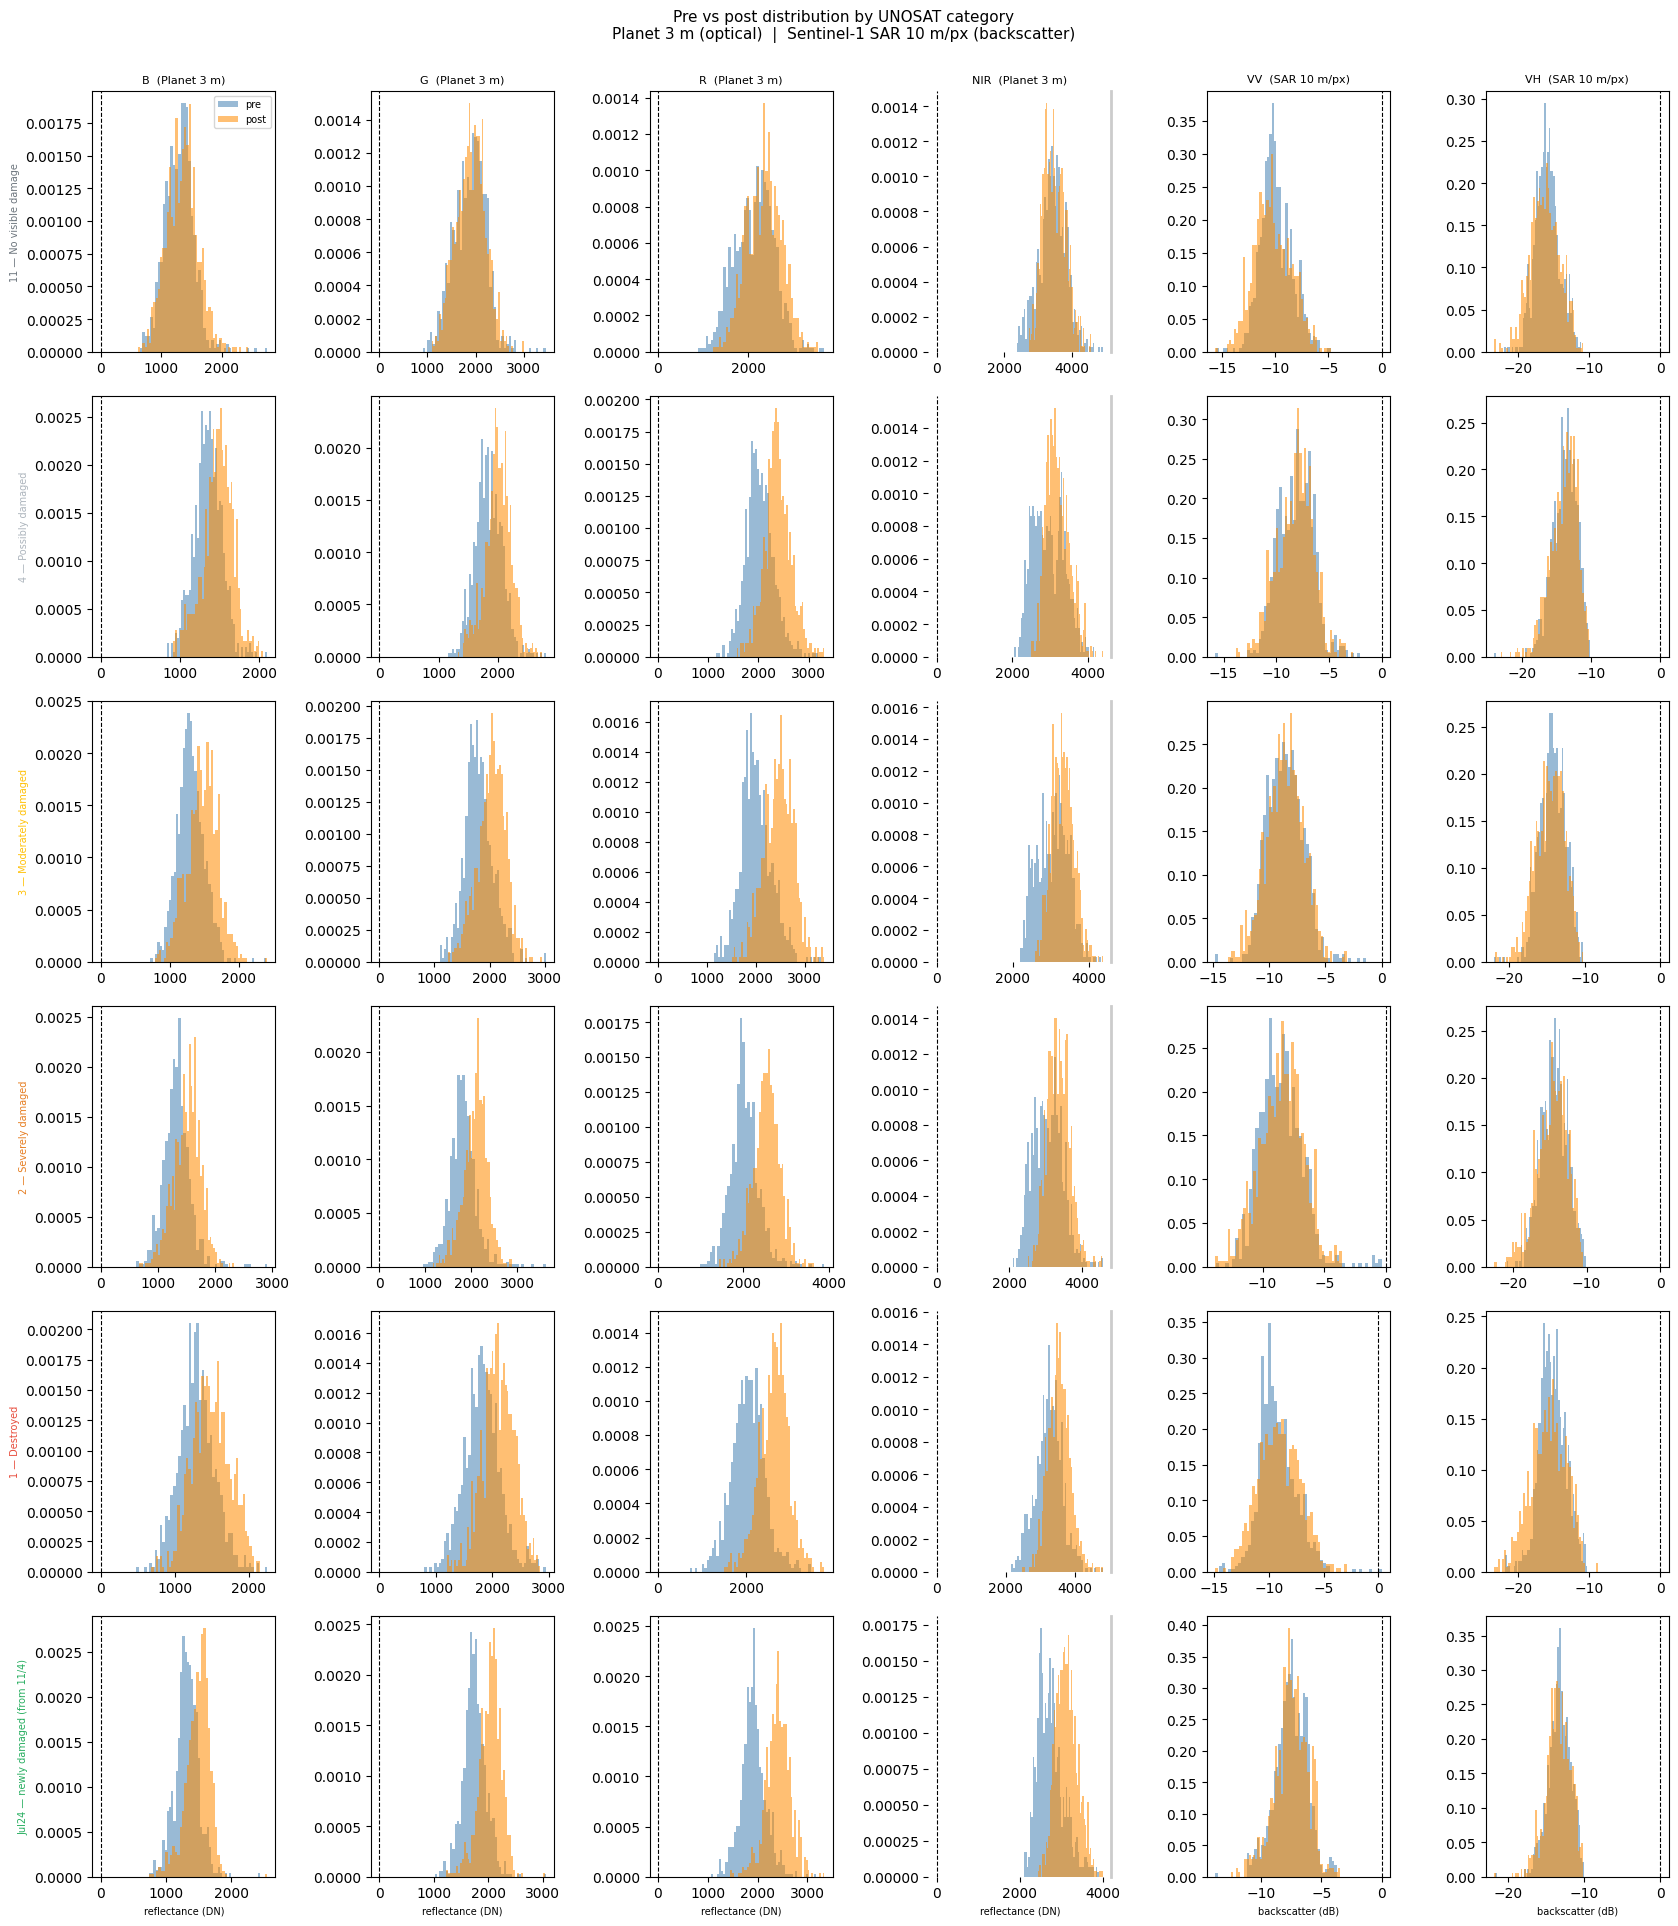

In [9]:
rng = np.random.default_rng(0)
N_SAMP = 800
FIGURES_DIR = PROJECT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Each panel: blue = pre-war distribution, orange = post-war distribution.
ALL_COLS = [
    ('B  (Planet 3 m)',    0, 4,  'reflectance (DN)'),
    ('G  (Planet 3 m)',    1, 5,  'reflectance (DN)'),
    ('R  (Planet 3 m)',    2, 6,  'reflectance (DN)'),
    ('NIR  (Planet 3 m)',  3, 7,  'reflectance (DN)'),
    ('VV  (SAR 10 m/px)',  8, 10, 'backscatter (dB)'),
    ('VH  (SAR 10 m/px)',  9, 11, 'backscatter (dB)'),
]
N_COLS = len(ALL_COLS)
N_ROWS = len(ORDER)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 2.8, 3.2 * N_ROWS))

for row_i, k in enumerate(ORDER):
    cat_idx = np.where(cat7 == k)[0]
    if len(cat_idx) == 0:
        for ax in axes[row_i]:
            ax.axis('off')
        continue
    sel = rng.choice(cat_idx, min(N_SAMP, len(cat_idx)), replace=False)
    m = X[sel].mean(axis=(2, 3))    # (n, 12) — patch-mean per channel

    for col_i, (title, pre_ch, post_ch, xlabel) in enumerate(ALL_COLS):
        ax = axes[row_i, col_i]
        pre_vals  = m[:, pre_ch]
        post_vals = m[:, post_ch]

        ax.hist(pre_vals,  bins=50, density=True, alpha=.55, color='steelblue',  label='pre')
        ax.hist(post_vals, bins=50, density=True, alpha=.55, color='darkorange', label='post')
        ax.axvline(0, color='black', linewidth=.8, linestyle='--')

        if row_i == 0:
            ax.set_title(title, fontsize=8)
        if row_i == N_ROWS - 1:
            ax.set_xlabel(xlabel, fontsize=7)
        if col_i == 0:
            ax.set_ylabel(CAT_META[k]['label'], fontsize=7, color=CAT_META[k]['color'])
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=7)

        if col_i == 3:
            for spine in ax.spines.values():
                spine.set_linewidth(0)
            ax.spines['right'].set_linewidth(2)
            ax.spines['right'].set_color('#cccccc')

plt.suptitle(
    'Pre vs post distribution by UNOSAT category\n'
    'Planet 3 m (optical)  |  Sentinel-1 SAR 10 m/px (backscatter)',
    y=1.001, fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
ALL_CH_NAMES = BANDS + SAR_BANDS        # ['B','G','R','NIR','VV','VH']
ALL_PRE_IDX  = PRE + SAR_PRE_IDX        # [0,1,2,3,8,9]
ALL_POST_IDX = POST + SAR_POST_IDX      # [4,5,6,7,10,11]

means_pre  = {k: [] for k in ORDER}
means_post = {k: [] for k in ORDER}
ndvi_delta = {k: [] for k in ORDER}
change     = {k: {b: [] for b in ALL_CH_NAMES} for k in ORDER}

for k in ORDER:
    idx = np.where(cat7 == k)[0]
    if len(idx) == 0:
        continue
    sel = rng.choice(idx, min(N_SAMP, len(idx)), replace=False)
    patches = X[sel]                                          # (n, 12, 32, 32)
    mp = patches[:, ALL_PRE_IDX].mean(axis=(2, 3))            # (n, 6) optical+SAR pre
    mq = patches[:, ALL_POST_IDX].mean(axis=(2, 3))           # (n, 6) optical+SAR post
    means_pre[k]  = mp
    means_post[k] = mq
    for j, b in enumerate(ALL_CH_NAMES):
        change[k][b] = (mq[:, j] - mp[:, j]).tolist()
    pre_ndvi  = (mp[:, 3] - mp[:, 2]) / np.maximum(mp[:, 3] + mp[:, 2], 1e-6)
    post_ndvi = (mq[:, 3] - mq[:, 2]) / np.maximum(mq[:, 3] + mq[:, 2], 1e-6)
    ndvi_delta[k] = (post_ndvi - pre_ndvi).tolist()

print('change / ndvi_delta computed for',
      sum(1 for k in ORDER if change[k][ALL_CH_NAMES[0]]), 'of', len(ORDER), 'categories.')

change / ndvi_delta computed for 6 of 6 categories.


band,B,G,R,NIR,VV,VH
category,,,,,,
11 — No visible damage,59.3,30.2,224.6,71.9,0.4,0.4
4 — Possibly damaged,121.7,150.9,340.5,222.4,0.1,0.2
3 — Moderately damaged,173.1,238.6,468.9,285.0,0.1,0.3
2 — Severely damaged,182.8,264.5,502.0,291.3,0.3,0.3
1 — Destroyed,204.1,299.6,598.7,302.3,0.4,0.7
Jul24 — newly damaged (from 11/4),172.5,295.3,490.7,388.4,0.1,0.2


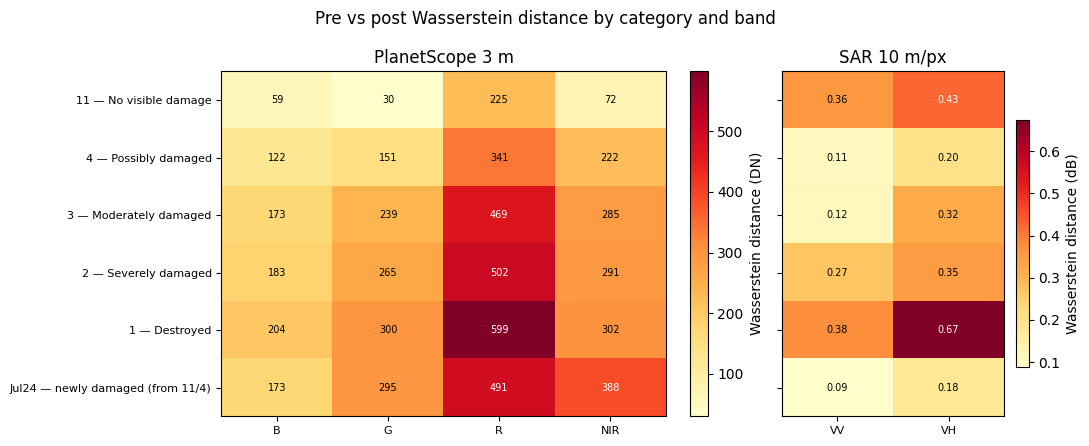

In [11]:
from scipy.stats import wasserstein_distance

ALL_BANDS = [
    ('B',   0,  4,  'Planet 3 m'),
    ('G',   1,  5,  'Planet 3 m'),
    ('R',   2,  6,  'Planet 3 m'),
    ('NIR', 3,  7,  'Planet 3 m'),
    ('VV',  8,  10, 'SAR 10 m/px'),
    ('VH',  9,  11, 'SAR 10 m/px'),
]
BAND_ORDER = [b for b, *_ in ALL_BANDS]

records = []
for k in ORDER:
    cat_idx = np.where(cat7 == k)[0]
    if len(cat_idx) == 0:
        continue
    sel = rng.choice(cat_idx, min(N_SAMP, len(cat_idx)), replace=False)
    m = X[sel].mean(axis=(2, 3))    # (n, 12)
    for band, pre_ch, post_ch, src in ALL_BANDS:
        wd = wasserstein_distance(m[:, pre_ch], m[:, post_ch])
        records.append({'category': CAT_META[k]['label'],
                         'band': band, 'source': src,
                         'wasserstein': wd, 'key': k})

wd_df = pd.DataFrame(records)
display(wd_df.pivot(index='category', columns='band', values='wasserstein')
             .reindex(index=[CAT_META[k]['label'] for k in ORDER], columns=BAND_ORDER)
             .round(1))

pivot = (wd_df.pivot(index='key', columns='band', values='wasserstein')
              .reindex(index=ORDER, columns=BAND_ORDER))

optical_bands = [b for b, _, _, src in ALL_BANDS if src == 'Planet 3 m']
sar_bands     = [b for b, _, _, src in ALL_BANDS if src == 'SAR 10 m/px']

pivot_opt = pivot.reindex(columns=optical_bands)
pivot_sar = pivot.reindex(columns=sar_bands)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                          gridspec_kw={'width_ratios': [len(optical_bands), len(sar_bands)]})

for ax, pv, title, unit, fmt in [
    (axes[0], pivot_opt, 'PlanetScope 3 m', 'DN', '{:.0f}'),
    (axes[1], pivot_sar, 'SAR 10 m/px',    'dB', '{:.2f}'),
]:
    im = ax.imshow(pv.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(pv.shape[1]))
    ax.set_xticklabels(pv.columns, fontsize=8)
    ax.set_yticks(range(len(ORDER)))
    ax.set_yticklabels([CAT_META[k]['label'] for k in ORDER], fontsize=8)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            val = pv.values[i, j]
            ax.text(j, i, fmt.format(val),
                    ha='center', va='center', fontsize=7,
                    color='white' if val > pv.values.max()*0.6 else 'black')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=.05, label=f'Wasserstein distance ({unit})')

axes[1].set_yticklabels([])

fig.suptitle('Pre vs post Wasserstein distance by category and band')
plt.tight_layout()
plt.show()

In [12]:
# Raw SAR channel stats before any sampling/averaging — sanity check for
# unit range, zero-fill from unmatched footprints, and outliers.
for name, idx in [('s1_pre_VV', 8), ('s1_pre_VH', 9), ('s1_post_VV', 10), ('s1_post_VH', 11)]:
    ch = X[:, idx]
    print(f"{name:12s}  min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f}  "
          f"std={ch.std():.3f}  frac_zero={(ch == 0).mean():.3%}  dtype={ch.dtype}")

s1_pre_VV     min=-25.719  max=19.703  mean=-8.871  std=2.916  frac_zero=0.000%  dtype=float32
s1_pre_VH     min=-30.234  max=20.344  mean=-14.661  std=3.214  frac_zero=0.000%  dtype=float32
s1_post_VV    min=-48.594  max=17.312  mean=-8.904  std=3.529  frac_zero=0.000%  dtype=float32
s1_post_VH    min=-57.094  max=12.531  mean=-15.025  std=4.218  frac_zero=0.000%  dtype=float32


c11 (no damage)  : 10,593 patches
c1  (destroyed)  : 34,093 patches


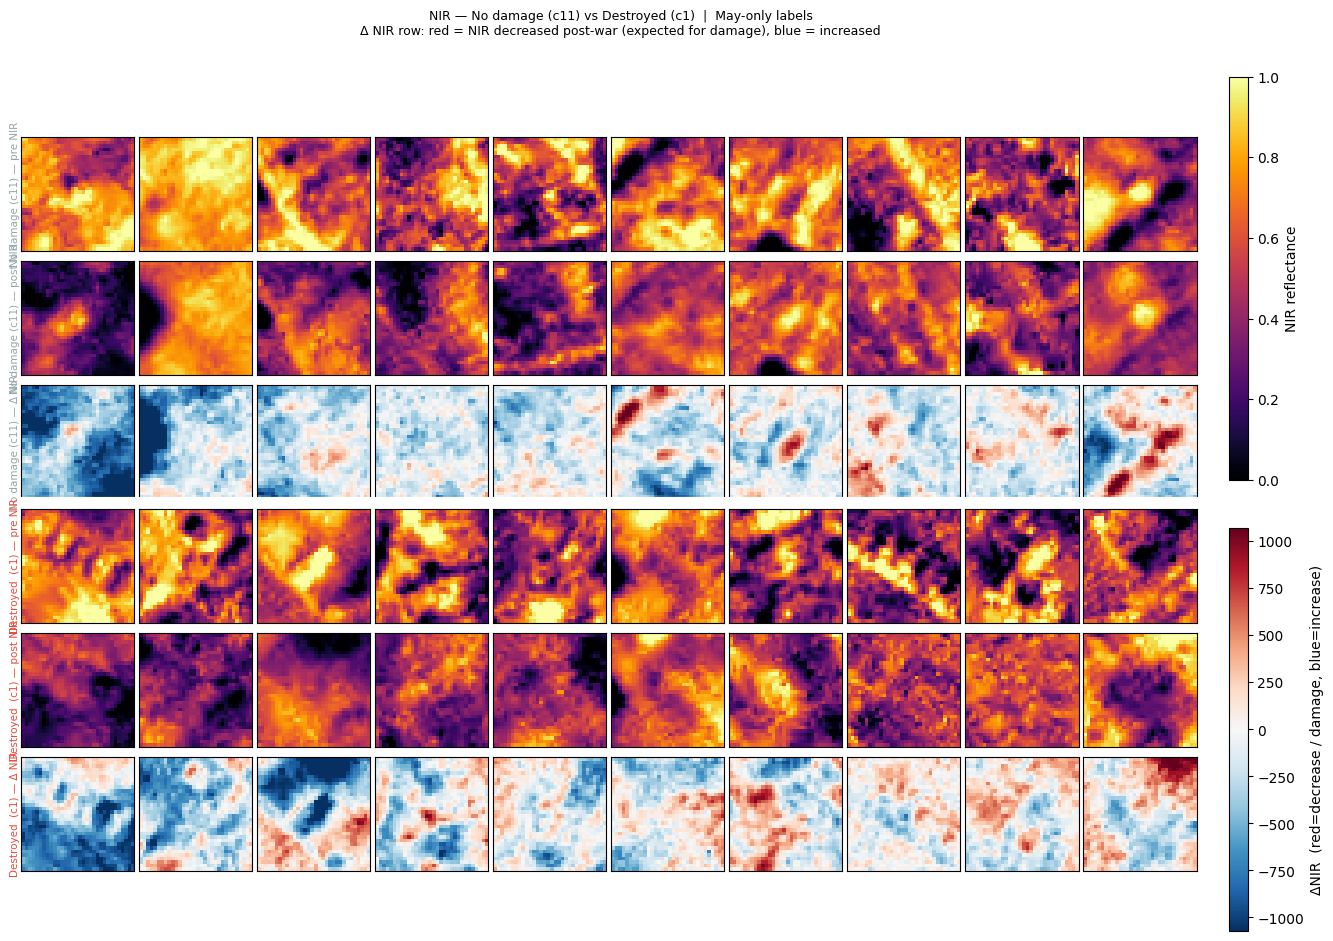

In [13]:
# Pools drawn only from directly May-labelled categories (c11, c1), so
# neither depends on the July-derived new_part category.
pool_intact  = np.where(cat7 == 'c11')[0]   # class 11 — no visible damage in May
pool_damaged = np.where(cat7 == 'c1')[0]    # class 1  — destroyed in May

print(f'c11 (no damage)  : {len(pool_intact):,} patches')
print(f'c1  (destroyed)  : {len(pool_damaged):,} patches')

N_EXAMPLES = 10

nir_pre_ch  = PRE[BANDS.index('NIR')]   # -> 3
nir_post_ch = POST[BANDS.index('NIR')]  # -> 7

def nir_triple(patch):
    pre      = patch[nir_pre_ch].astype(float)
    post     = patch[nir_post_ch].astype(float)
    both     = np.concatenate([pre.ravel(), post.ravel()])
    lo, hi   = np.percentile(both, [2, 98])
    scale    = max(hi - lo, 1e-6)
    pre_s    = np.clip((pre  - lo) / scale, 0, 1)
    post_s   = np.clip((post - lo) / scale, 0, 1)
    diff_img = post - pre
    delta    = diff_img.mean()               # scalar for sorting
    return pre_s, post_s, diff_img, delta

# sort each pool by NIR delta: intact -> least change first, damaged -> most decrease first
def sorted_sample(pool, n, ascending=True):
    chosen = rng.choice(pool, size=min(n * 4, len(pool)), replace=False)
    deltas = np.array([nir_triple(X[j])[3] for j in chosen])
    order  = np.argsort(deltas) if ascending else np.argsort(deltas)[::-1]
    return chosen[order[:n]]

intact_idx  = sorted_sample(pool_intact,  N_EXAMPLES, ascending=True)
damaged_idx = sorted_sample(pool_damaged, N_EXAMPLES, ascending=True)

all_diff_imgs = [nir_triple(X[j])[2] for j in np.concatenate([intact_idx, damaged_idx])]
diff_lim = np.percentile(np.abs(np.concatenate([d.ravel() for d in all_diff_imgs])), 98)

row_labels = [
    'No damage (c11) — pre NIR',
    'No damage (c11) — post NIR',
    'No damage (c11) — Δ NIR',
    'Destroyed  (c1) — pre NIR',
    'Destroyed  (c1) — post NIR',
    'Destroyed  (c1) — Δ NIR',
]

fig, axes = plt.subplots(6, N_EXAMPLES, figsize=(N_EXAMPLES * 1.6, 6 * 1.6))

for col, j in enumerate(intact_idx):
    pre, post, diff_img, _ = nir_triple(X[j])
    axes[0, col].imshow(pre,      cmap='inferno', vmin=0, vmax=1)
    axes[1, col].imshow(post,     cmap='inferno', vmin=0, vmax=1)
    axes[2, col].imshow(diff_img, cmap='RdBu_r',  vmin=-diff_lim, vmax=diff_lim)

for col, j in enumerate(damaged_idx):
    pre, post, diff_img, _ = nir_triple(X[j])
    axes[3, col].imshow(pre,      cmap='inferno', vmin=0, vmax=1)
    axes[4, col].imshow(post,     cmap='inferno', vmin=0, vmax=1)
    axes[5, col].imshow(diff_img, cmap='RdBu_r',  vmin=-diff_lim, vmax=diff_lim)

for col in range(N_EXAMPLES):
    for row in range(6):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 2:
            axes[row, col].spines['bottom'].set_linewidth(3)
            axes[row, col].spines['bottom'].set_color('white')

for row, label in enumerate(row_labels):
    color = '#95A5A6' if row < 3 else '#E74C3C'
    axes[row, 0].set_ylabel(label, fontsize=7.5, rotation=90,
                             labelpad=4, va='center', color=color)

fig.subplots_adjust(right=0.86, hspace=0.04, wspace=0.04)
cb1 = fig.add_axes([0.88, 0.52, 0.012, 0.42])
fig.colorbar(plt.cm.ScalarMappable(cmap='inferno',
             norm=plt.Normalize(0, 1)), cax=cb1, label='NIR reflectance')

cb2 = fig.add_axes([0.88, 0.05, 0.012, 0.42])
fig.colorbar(plt.cm.ScalarMappable(cmap='RdBu_r',
             norm=plt.Normalize(-diff_lim, diff_lim)),
             cax=cb2, label='ΔNIR  (red=decrease / damage, blue=increase)')

plt.suptitle(
    'NIR — No damage (c11) vs Destroyed (c1)  |  May-only labels\n'
    'Δ NIR row: red = NIR decreased post-war (expected for damage), blue = increased',
    y=1.01, fontsize=9)
plt.show()

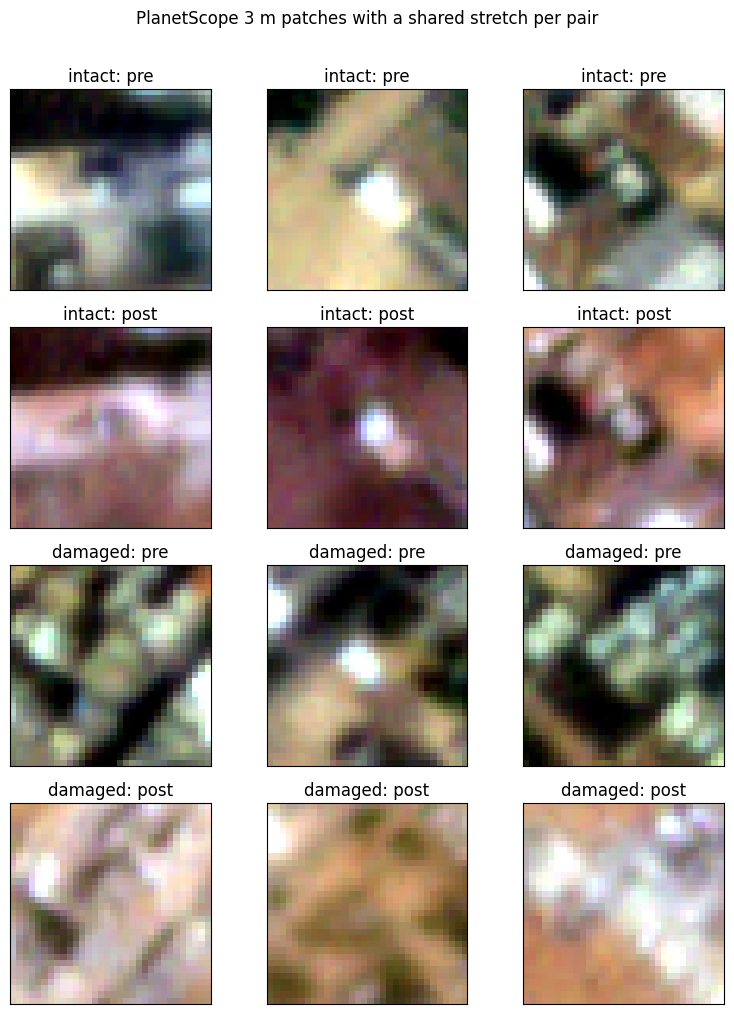

In [27]:
# Example pre/post RGB pairs. Percentile scaling is shared within each pair.
rgb_pre_idx  = [PRE[BANDS.index(c)]  for c in ('R', 'G', 'B')]
rgb_post_idx = [POST[BANDS.index(c)] for c in ('R', 'G', 'B')]

def rgb_pair(patch):
    pre = np.moveaxis(patch[rgb_pre_idx], 0, -1)
    post = np.moveaxis(patch[rgb_post_idx], 0, -1)
    both = np.concatenate([pre.reshape(-1, 3), post.reshape(-1, 3)], axis=0)
    lo, hi = np.percentile(both, [2, 98], axis=0)
    scale = np.maximum(hi - lo, 1e-6)
    return np.clip((pre - lo) / scale, 0, 1), np.clip((post - lo) / scale, 0, 1)

rgb_rng = np.random.default_rng(7)   # separate seed — change this to get a different set of examples

examples = []
examples.extend(rgb_rng.choice(pool_intact,  size=3, replace=False))
examples.extend(rgb_rng.choice(pool_damaged, size=3, replace=False))

fig, axes = plt.subplots(4, 3, figsize=(8, 10))
for col, j in enumerate(examples[:3]):
    pre, post = rgb_pair(X[j])
    axes[0, col].imshow(pre); axes[1, col].imshow(post)
    axes[0, col].set_title('intact: pre'); axes[1, col].set_title('intact: post')
for col, j in enumerate(examples[3:]):
    pre, post = rgb_pair(X[j])
    axes[2, col].imshow(pre); axes[3, col].imshow(post)
    axes[2, col].set_title('damaged: pre'); axes[3, col].set_title('damaged: post')
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('PlanetScope 3 m patches with a shared stretch per pair', y=1.01)
plt.tight_layout()
plt.show()

### A2 — Post-minus-pre change distributions by band

Each panel is one spectral band. Distributions shift left (more negative) as
damage severity increases, with destroyed and newly-damaged buildings
showing the strongest signal.

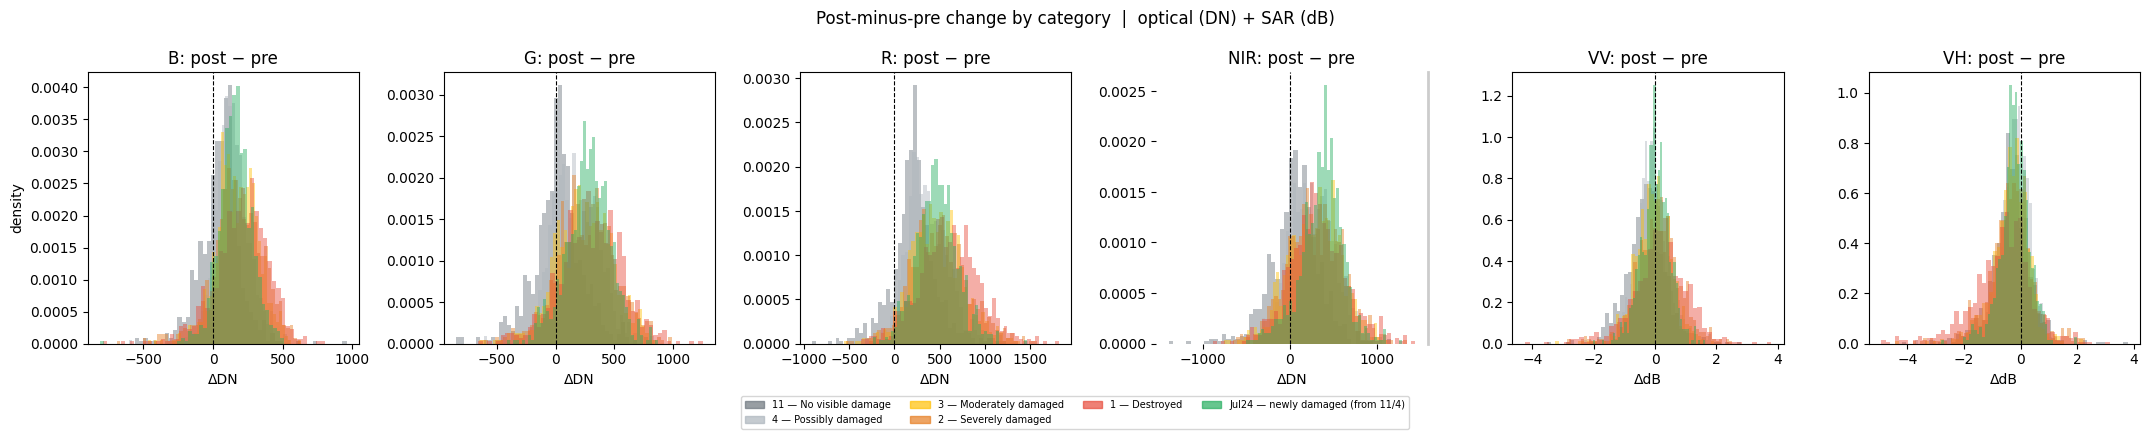

In [14]:
CH_UNITS = {'B':'ΔDN','G':'ΔDN','R':'ΔDN','NIR':'ΔDN','VV':'ΔdB','VH':'ΔdB'}

fig, axes = plt.subplots(1, len(ALL_CH_NAMES), figsize=(3.6*len(ALL_CH_NAMES), 4))
for j, (ax, band) in enumerate(zip(axes, ALL_CH_NAMES)):
    for k in ORDER:
        vals = change[k][band]
        if not vals: continue
        ax.hist(vals, bins=50, density=True, alpha=.45,
                color=CAT_META[k]['color'], label=CAT_META[k]['label'])
    ax.axvline(0, color='k', lw=.8, ls='--')
    ax.set_title(f'{band}: post − pre'); ax.set_xlabel(CH_UNITS[band])
    ax.set_ylabel('density' if j==0 else '')
    if band == 'NIR':   # divider between optical and SAR columns
        for spine in ax.spines.values():
            spine.set_linewidth(0)
        ax.spines['right'].set_linewidth(2)
        ax.spines['right'].set_color('#cccccc')
handles = [Patch(color=CAT_META[k]['color'], alpha=.7, label=CAT_META[k]['label'])
           for k in ORDER]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=7,
           bbox_to_anchor=(.5, -.08))
plt.suptitle('Post-minus-pre change by category  |  optical (DN) + SAR (dB)')
plt.tight_layout()
plt.show()

### A3 — NDVI change and summary severity gradient

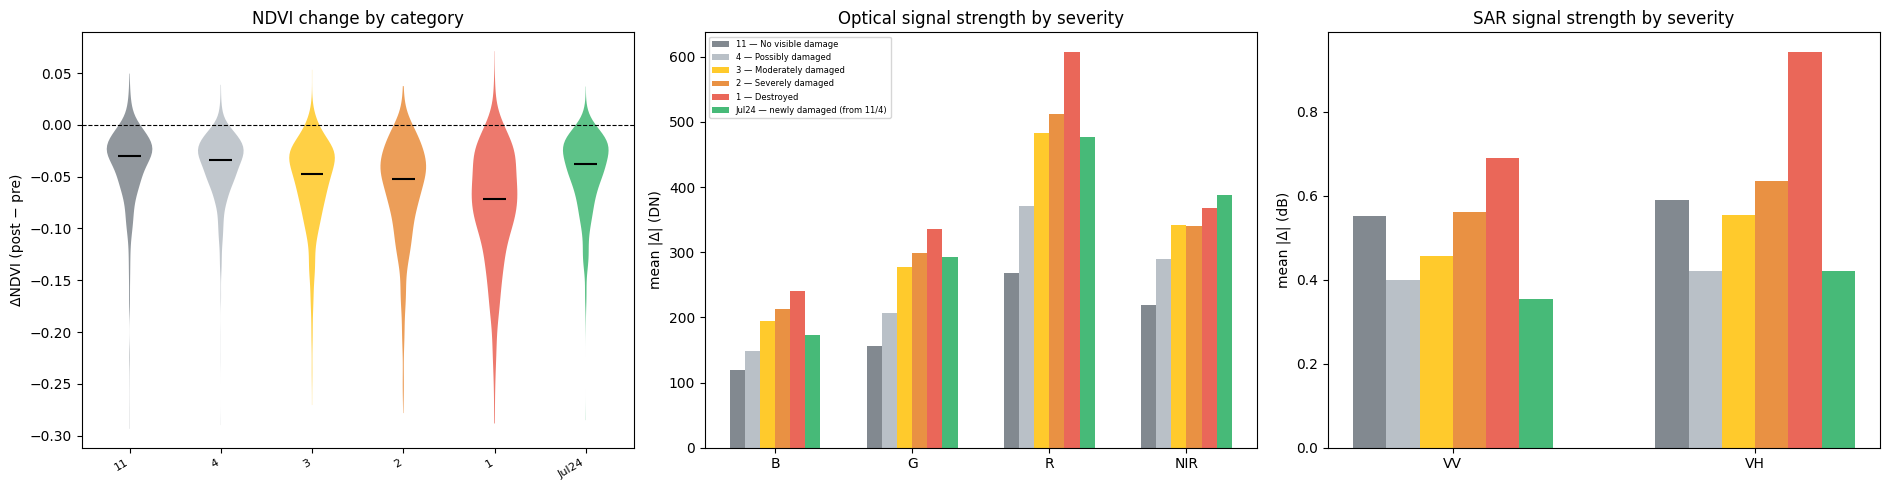

Median ΔNDVI per category:
  11 — No visible damage                   -0.0295
  4 — Possibly damaged                     -0.0334
  3 — Moderately damaged                   -0.0470
  2 — Severely damaged                     -0.0523
  1 — Destroyed                            -0.0716
  Jul24 — newly damaged (from 11/4)        -0.0380


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# left: NDVI change violin (optical-only — NDVI has no SAR analogue)
parts = [np.array(ndvi_delta[k]) for k in ORDER if ndvi_delta[k]]
labels_used = [k for k in ORDER if ndvi_delta[k]]
vp = axes[0].violinplot(parts, showmedians=True, showextrema=False)
for body, k in zip(vp['bodies'], labels_used):
    body.set_facecolor(CAT_META[k]['color']); body.set_alpha(.75)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(1.5)
axes[0].axhline(0, color='k', lw=.8, ls='--')
axes[0].set_xticks(range(1, len(labels_used)+1))
axes[0].set_xticklabels([CAT_META[k]['label'].split('—')[0].strip()
                          for k in labels_used], rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('ΔNDVI (post − pre)'); axes[0].set_title('NDVI change by category')

# middle: mean |Δ| per optical band as grouped bars (severity gradient)
width = 0.11
band_means_opt = {k: [np.abs(change[k][b]).mean() if change[k][b] else 0
                       for b in BANDS] for k in ORDER}
x = np.arange(len(BANDS))
for i, k in enumerate(ORDER):
    axes[1].bar(x + i*width, band_means_opt[k], width, color=CAT_META[k]['color'],
                alpha=.85, label=CAT_META[k]['label'])
axes[1].set_xticks(x + width*(len(ORDER)-1)/2); axes[1].set_xticklabels(BANDS)
axes[1].set_ylabel('mean |Δ| (DN)'); axes[1].set_title('Optical signal strength by severity')
axes[1].legend(fontsize=6, ncol=1)

# right: same, for SAR bands — separate axis since dB and DN deltas aren't comparable magnitudes
band_means_sar = {k: [np.abs(change[k][b]).mean() if change[k][b] else 0
                       for b in SAR_BANDS] for k in ORDER}
xs = np.arange(len(SAR_BANDS))
for i, k in enumerate(ORDER):
    axes[2].bar(xs + i*width, band_means_sar[k], width, color=CAT_META[k]['color'], alpha=.85)
axes[2].set_xticks(xs + width*(len(ORDER)-1)/2); axes[2].set_xticklabels(SAR_BANDS)
axes[2].set_ylabel('mean |Δ| (dB)'); axes[2].set_title('SAR signal strength by severity')

plt.tight_layout()
plt.show()

print('Median ΔNDVI per category:')
for k in ORDER:
    v = ndvi_delta[k]
    if v: print(f'  {CAT_META[k]["label"]:40s} {np.median(v):+.4f}')

## B · Spatial clustering and data-leakage risk

### B1 — Local damage rate via KNN

For every footprint, find its k=20 nearest geographic neighbours and compute
what fraction of them are labelled damaged. A high local rate next to a
building labelled intact is the clearest single-point indicator of label
noise — either a genuine UNOSAT miss, or a building labelled in May before
July destruction reached it.

In [16]:
x_utm = table_utm.geometry.centroid.x.values
y_utm = table_utm.geometry.centroid.y.values
coords = np.column_stack([x_utm, y_utm])

K = 20
print(f'Building KNN tree for {len(coords):,} footprints (k={K}) …')
tree = cKDTree(coords)
dists, nbr_idx = tree.query(coords, k=K+1)   # k+1 because first result is self
nbr_idx = nbr_idx[:, 1:]                      # exclude self
local_rate = y_binary[nbr_idx].mean(axis=1)   # fraction of k neighbours that are damaged

table['local_rate'] = local_rate
table['x_utm'] = x_utm
table['y_utm'] = y_utm

print(f'Global prevalence          : {100*y_binary.mean():.1f}%')
print(f'Mean local rate (k={K})    : {100*local_rate.mean():.1f}%')
print(f'Corr(local_rate, label)    : {np.corrcoef(local_rate, y_binary)[0,1]:.3f}')

Building KNN tree for 188,874 footprints (k=20) …
Global prevalence          : 53.8%
Mean local rate (k=20)    : 54.4%
Corr(local_rate, label)    : 0.767


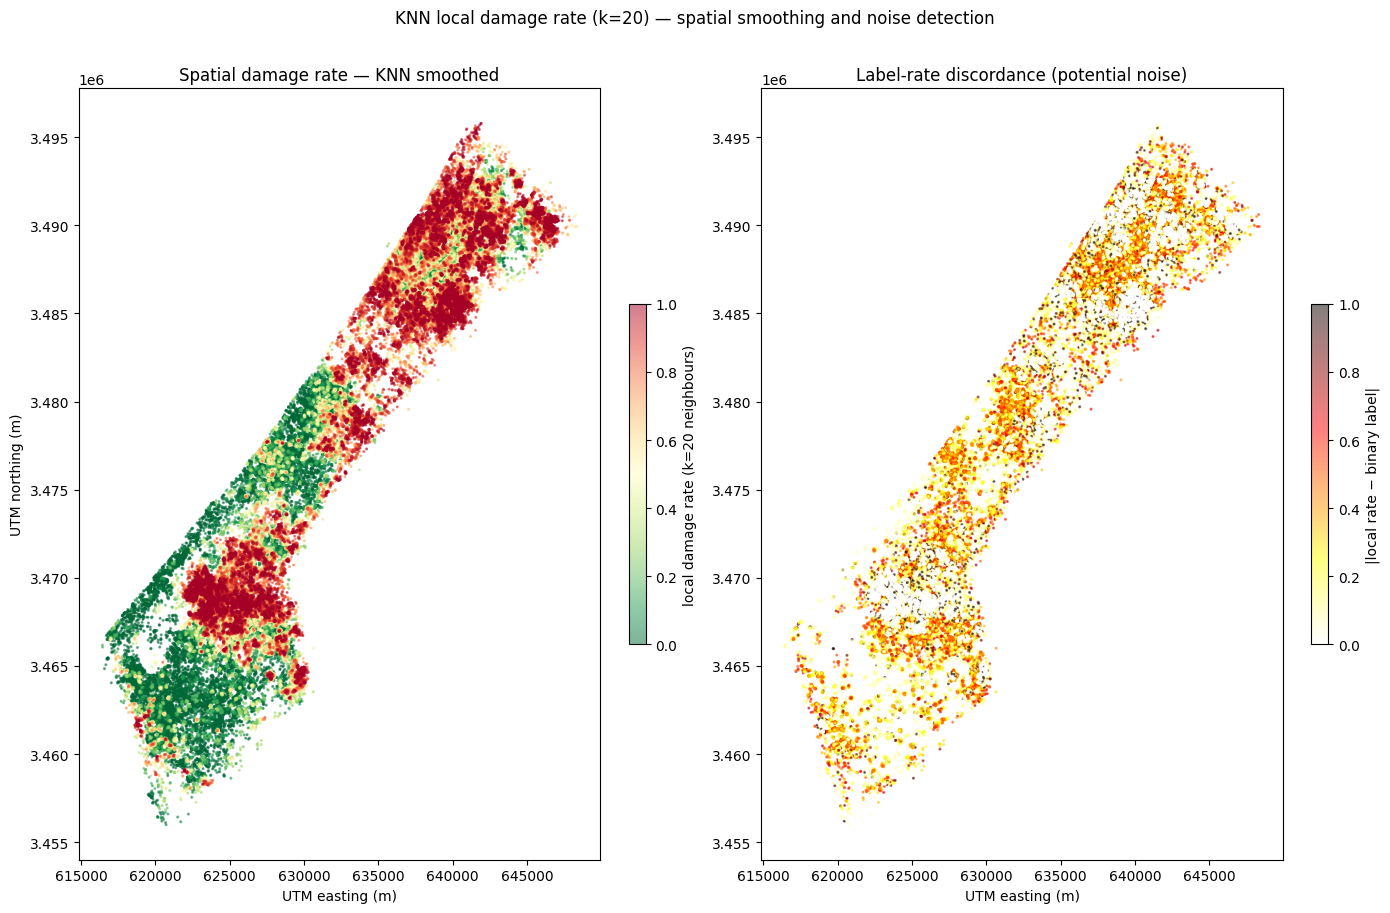

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

samp = rng.choice(len(table), min(60_000, len(table)), replace=False)
samp = samp[np.argsort(local_rate[samp])]   # draw low-rate first so high-rate visible

sc = axes[0].scatter(table['x_utm'].iloc[samp], table['y_utm'].iloc[samp],
                     c=local_rate[samp], cmap='RdYlGn_r',
                     s=1.5, alpha=.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], fraction=.03, label='local damage rate (k=20 neighbours)')
axes[0].set_title('Spatial damage rate — KNN smoothed')
axes[0].set_xlabel('UTM easting (m)'); axes[0].set_ylabel('UTM northing (m)')

disc = np.abs(local_rate - y_binary)      # 0 if agree, 1 if completely disagree
axes[1].scatter(table['x_utm'].iloc[samp], table['y_utm'].iloc[samp],
                c=disc[samp], cmap='hot_r', s=1.5, alpha=.5, vmin=0, vmax=1)
plt.colorbar(axes[1].collections[0], ax=axes[1], fraction=.03,
             label='|local rate − binary label|')
axes[1].set_title('Label-rate discordance (potential noise)')
axes[1].set_xlabel('UTM easting (m)')

plt.suptitle('KNN local damage rate (k=20) — spatial smoothing and noise detection', y=1.01)
plt.tight_layout()
plt.show()

### B2 — Data-leakage risk: random vs geographic split

Two footprints leak into each other whenever their extraction patches
physically overlap on the ground, not at some arbitrary fixed distance. This
dataset fuses two patch geometries per footprint — a 96 m PlanetScope window
and a 320 m Sentinel-1 SAR window, the latter being the binding constraint —
so overlap is assessed at both scales below.

Splits are built as contiguous latitude-quantile bands: train ≥0.55,
stack 0.44–0.55, val 0.33–0.44, test <0.33.

Median nearest-neighbour spacing (any footprint to any other): 16.5 m
nn_rand_dist  — min: 0.0m  median: 20.4m  max: 868.8m
nn_geo_dist   — min: 8773.1m  median: 13377.0m  max: 22946.4m

Geographic split — test pts within Planet (96 m) of a train pt: 0.0%
Random split      — test pts within Planet (96 m) of a train pt: 98.9%
Geographic split — test pts within SAR (320 m) of a train pt: 0.0%
Random split      — test pts within SAR (320 m) of a train pt: 100.0%


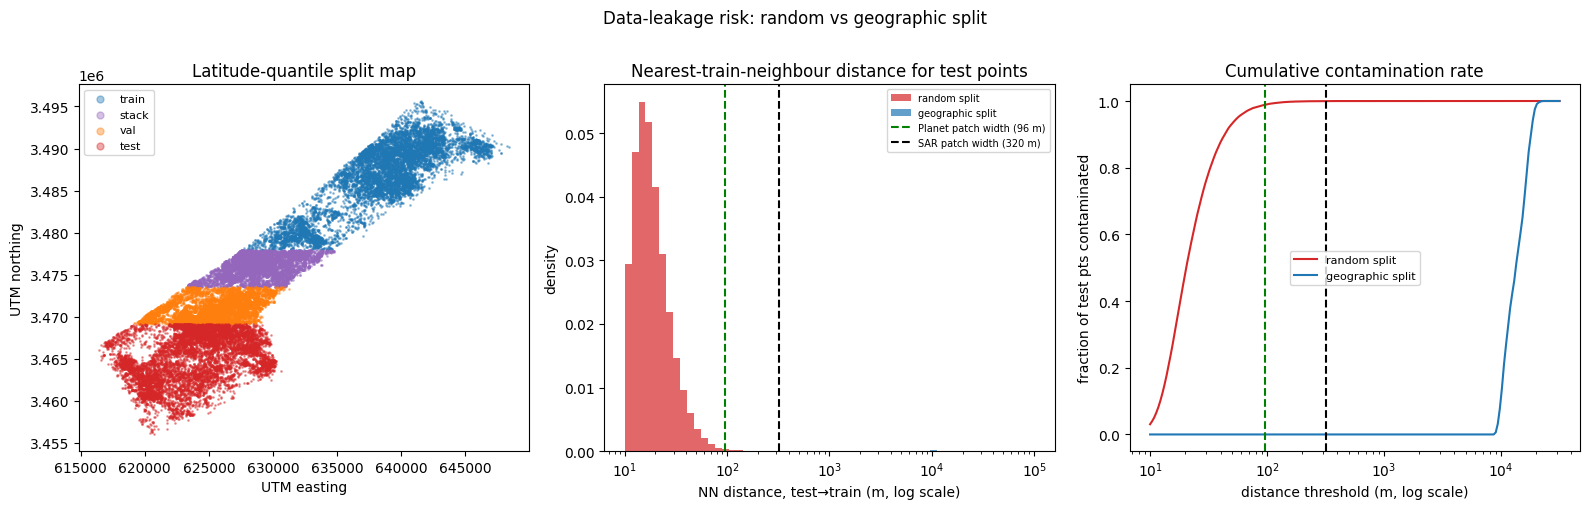

In [18]:
lat = table['y_utm'].values if 'y_utm' in table.columns else y_utm
lat_pct = (lat - lat.min()) / (lat.max() - lat.min())

splits = {
    'train': np.where(lat_pct >= 0.55)[0],
    'stack': np.where((lat_pct >= 0.44) & (lat_pct < 0.55))[0],
    'val':   np.where((lat_pct >= 0.33) & (lat_pct < 0.44))[0],
    'test':  np.where(lat_pct < 0.33)[0],
}
SPLIT_COLORS = {'train': 'tab:blue', 'stack': 'tab:purple', 'val': 'tab:orange', 'test': 'tab:red'}
roles = ['train', 'stack', 'val', 'test']

train_coords = coords[splits['train']]
test_coords  = coords[splits['test']]
tree_train   = cKDTree(train_coords)
nn_geo_dist, _ = tree_train.query(test_coords, k=1)

# random-split baseline: same train/test sizes, no spatial structure
rng_base = np.random.default_rng(42)
all_idx = np.arange(len(coords))
rng_base.shuffle(all_idx)
n_train = len(splits['train'])
train_rand = all_idx[:n_train]
test_rand  = all_idx[n_train + len(splits['stack']) + len(splits['val']):]
tree_rand  = cKDTree(coords[train_rand])
nn_rand_dist, _ = tree_rand.query(coords[test_rand], k=1)

sample_idx = rng.choice(len(coords), 5000, replace=False)
nn_all_dist, _ = cKDTree(coords).query(coords[sample_idx], k=2)  # k=2: nearest OTHER point
median_spacing = np.median(nn_all_dist[:, 1])

print(f'Median nearest-neighbour spacing (any footprint to any other): {median_spacing:.1f} m')
print(f'nn_rand_dist  — min: {nn_rand_dist.min():.1f}m  median: {np.median(nn_rand_dist):.1f}m  max: {nn_rand_dist.max():.1f}m')
print(f'nn_geo_dist   — min: {nn_geo_dist.min():.1f}m  median: {np.median(nn_geo_dist):.1f}m  max: {nn_geo_dist.max():.1f}m')
print()
for label, dist in [('Planet (96 m)', PATCH_M_PLANET), ('SAR (320 m)', PATCH_M_SAR)]:
    print(f'Geographic split — test pts within {label} of a train pt: '
          f'{100*(nn_geo_dist < dist).mean():.1f}%')
    print(f'Random split      — test pts within {label} of a train pt: '
          f'{100*(nn_rand_dist < dist).mean():.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for role, color in SPLIT_COLORS.items():
    idx = splits[role]
    s = rng.choice(idx, min(10000, len(idx)), replace=False)
    axes[0].scatter(coords[s, 0], coords[s, 1], c=color, s=1, alpha=.4, label=role)
axes[0].legend(markerscale=5, fontsize=8)
axes[0].set_title('Latitude-quantile split map')
axes[0].set_xlabel('UTM easting'); axes[0].set_ylabel('UTM northing')

bins = np.logspace(1, 5, 60)
axes[1].hist(nn_rand_dist, bins=bins, density=True, alpha=.7, label='random split', color='tab:red')
axes[1].hist(nn_geo_dist,  bins=bins, density=True, alpha=.7, label='geographic split', color='tab:blue')
axes[1].axvline(PATCH_M_PLANET, color='green', ls='--', lw=1.5, label=f'Planet patch width ({PATCH_M_PLANET} m)')
axes[1].axvline(PATCH_M_SAR, color='black', ls='--', lw=1.5, label=f'SAR patch width ({PATCH_M_SAR} m)')
axes[1].set_xscale('log')
axes[1].set_xlabel('NN distance, test→train (m, log scale)')
axes[1].set_ylabel('density')
axes[1].set_title('Nearest-train-neighbour distance for test points')
axes[1].legend(fontsize=7)

thresholds = np.logspace(1, 4.5, 200)
axes[2].plot(thresholds, [(nn_rand_dist < t).mean() for t in thresholds], color='tab:red', label='random split')
axes[2].plot(thresholds, [(nn_geo_dist < t).mean() for t in thresholds], color='tab:blue', label='geographic split')
axes[2].axvline(PATCH_M_PLANET, color='green', ls='--', lw=1.5)
axes[2].axvline(PATCH_M_SAR, color='black', ls='--', lw=1.5)
axes[2].set_xscale('log')
axes[2].set_xlabel('distance threshold (m, log scale)')
axes[2].set_ylabel('fraction of test pts contaminated')
axes[2].set_title('Cumulative contamination rate')
axes[2].legend(fontsize=8)

plt.suptitle('Data-leakage risk: random vs geographic split', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Exact axis-aligned overlap check (Chebyshev distance), all four split-pair
# boundaries, both patch widths. The train/test pair is separated by a wide
# buffer (stack + val sit between them); the three adjacent pairs share a
# ~0m boundary since the quantile bands are contiguous by construction.
def patch_overlap_fraction(test_coords, train_coords, patch_m):
    tree = cKDTree(train_coords)
    pairs = tree.query_ball_point(test_coords, r=patch_m * np.sqrt(2))
    overlapping = np.zeros(len(test_coords), dtype=bool)
    for i, neighbor_idxs in enumerate(pairs):
        if not neighbor_idxs:
            continue
        dx = np.abs(train_coords[neighbor_idxs, 0] - test_coords[i, 0])
        dy = np.abs(train_coords[neighbor_idxs, 1] - test_coords[i, 1])
        overlapping[i] = np.any((dx < patch_m) & (dy < patch_m))
    return overlapping.mean()

split_pairs_all = [('train', 'test'), ('train', 'stack'), ('stack', 'val'), ('val', 'test')]
gaps = {}
for a, b in split_pairs_all:
    ya = coords[splits[a], 1]
    yb = coords[splits[b], 1]
    gaps[(a, b)] = min(ya) - max(yb) if min(ya) > max(yb) else min(yb) - max(ya)

print(f'{"pair":16s} {"gap (m)":>10s} {"Planet 96m":>12s} {"SAR 320m":>12s}')
for a, b in split_pairs_all:
    coords_a = coords[splits[a]]
    coords_b = coords[splits[b]]
    ov_planet = patch_overlap_fraction(coords_b, coords_a, PATCH_M_PLANET)
    ov_sar    = patch_overlap_fraction(coords_b, coords_a, PATCH_M_SAR)
    print(f'{a}<->{b:10s} {gaps[(a,b)]:>10,.0f} {100*ov_planet:>11.1f}% {100*ov_sar:>11.1f}%')

ov_planet_rand = patch_overlap_fraction(coords[test_rand], coords[train_rand], PATCH_M_PLANET)
ov_sar_rand    = patch_overlap_fraction(coords[test_rand], coords[train_rand], PATCH_M_SAR)
print(f'\n{"random split":16s} {"":>10s} {100*ov_planet_rand:>11.1f}% {100*ov_sar_rand:>11.1f}%')

print('\nThe outer train/test boundary is leakage-free at both patch scales. '
      'The three internal boundaries carry no spatial buffer and retain '
      'measurable overlap — relevant for any configuration that trains on '
      'stack alongside train, or evaluates on val immediately adjacent to stack.')

pair                gap (m)   Planet 96m     SAR 320m
train<->test            8,760         0.0%         0.0%
train<->stack               1         2.8%        10.2%
stack<->val                 1         0.7%         2.8%
val<->test                0         1.3%         4.8%

random split                       99.2%       100.0%

The outer train/test boundary is leakage-free at both patch scales. The three internal boundaries carry no spatial buffer and retain measurable overlap — relevant for any configuration that trains on stack alongside train, or evaluates on val immediately adjacent to stack.


## C · Systematic split comparison

Label rule for all plots: **UNOSAT classes 1–3 = damaged, class 4 and 11 = intact**
(class 6 and unmatched treated as intact in the binary label).

In [20]:
rows = []
for role in roles:
    idx = splits[role]
    y_r = y_binary[idx]
    lat_r = lat[idx]
    area_r = table.iloc[idx]['area'].values if 'area' in table.columns else np.full(len(idx), np.nan)
    local_r = local_rate[idx]

    cat_r = cat7[idx]
    cat_counts = {k: (cat_r == k).sum() for k in ORDER}

    rows.append({
        'role':             role,
        'n':                len(idx),
        'prevalence (%)':   round(100*y_r.mean(), 1),
        'lat range (km)':   f'{(lat_r.max()-lat_r.min())/1000:.1f}',
        'median area (m²)': round(np.nanmedian(area_r), 0),
        'mean local rate':  round(local_r.mean(), 3),
        **{f'n_{k}': cat_counts[k] for k in ORDER},
    })
summary = pd.DataFrame(rows).set_index('role')
print('Split summary:')
display(summary[['n', 'prevalence (%)', 'lat range (km)', 'median area (m²)', 'mean local rate']])

Split summary:


,n,prevalence (%),lat range (km),median area (m²),mean local rate
role,,,,,
train,94645,66.4,17.9,172.0,0.670
stack,17655,24.0,4.4,153.0,0.246
val,19330,64.4,4.4,141.0,0.652
test,57244,38.5,13.1,150.0,0.391


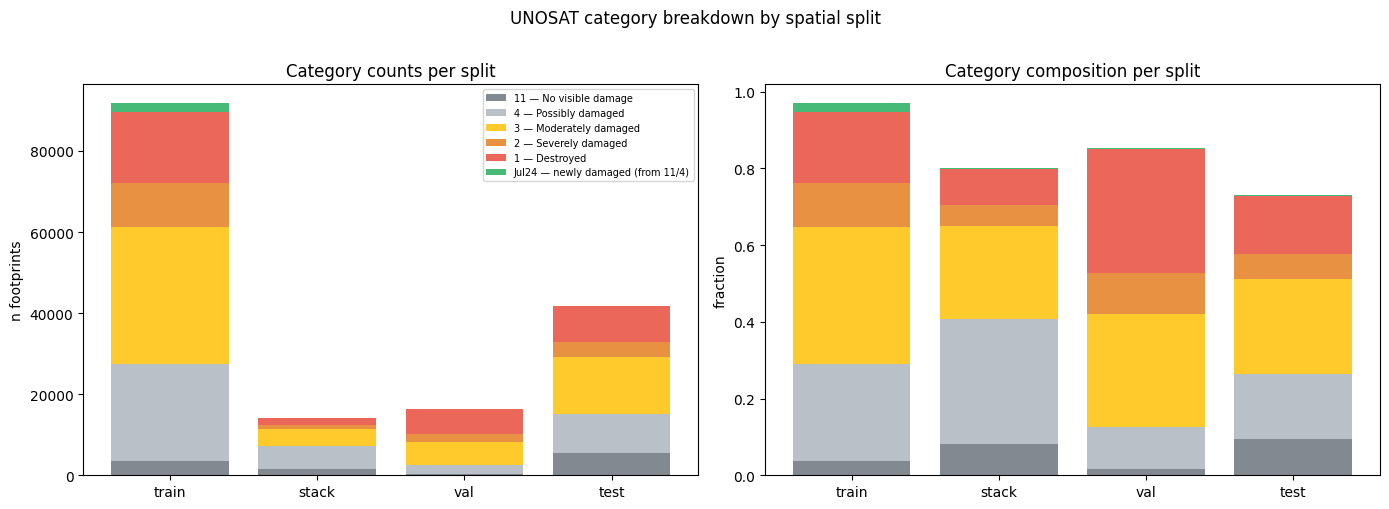

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(roles))

bottom = np.zeros(len(roles))
for k in ORDER:
    vals = np.array([summary.loc[r, f'n_{k}'] for r in roles])
    axes[0].bar(x, vals, bottom=bottom, color=CAT_META[k]['color'], alpha=.85, label=CAT_META[k]['label'])
    bottom += vals
axes[0].set_xticks(x); axes[0].set_xticklabels(roles)
axes[0].set_ylabel('n footprints'); axes[0].set_title('Category counts per split')
axes[0].legend(fontsize=7, loc='upper right')

total = np.array([summary.loc[r, 'n'] for r in roles], float)
bottom = np.zeros(len(roles))
for k in ORDER:
    vals = np.array([summary.loc[r, f'n_{k}'] for r in roles]) / total
    axes[1].bar(x, vals, bottom=bottom, color=CAT_META[k]['color'], alpha=.85)
    bottom += vals
axes[1].set_xticks(x); axes[1].set_xticklabels(roles)
axes[1].set_ylabel('fraction'); axes[1].set_title('Category composition per split')

plt.suptitle('UNOSAT category breakdown by spatial split', y=1.01)
plt.tight_layout()
plt.show()

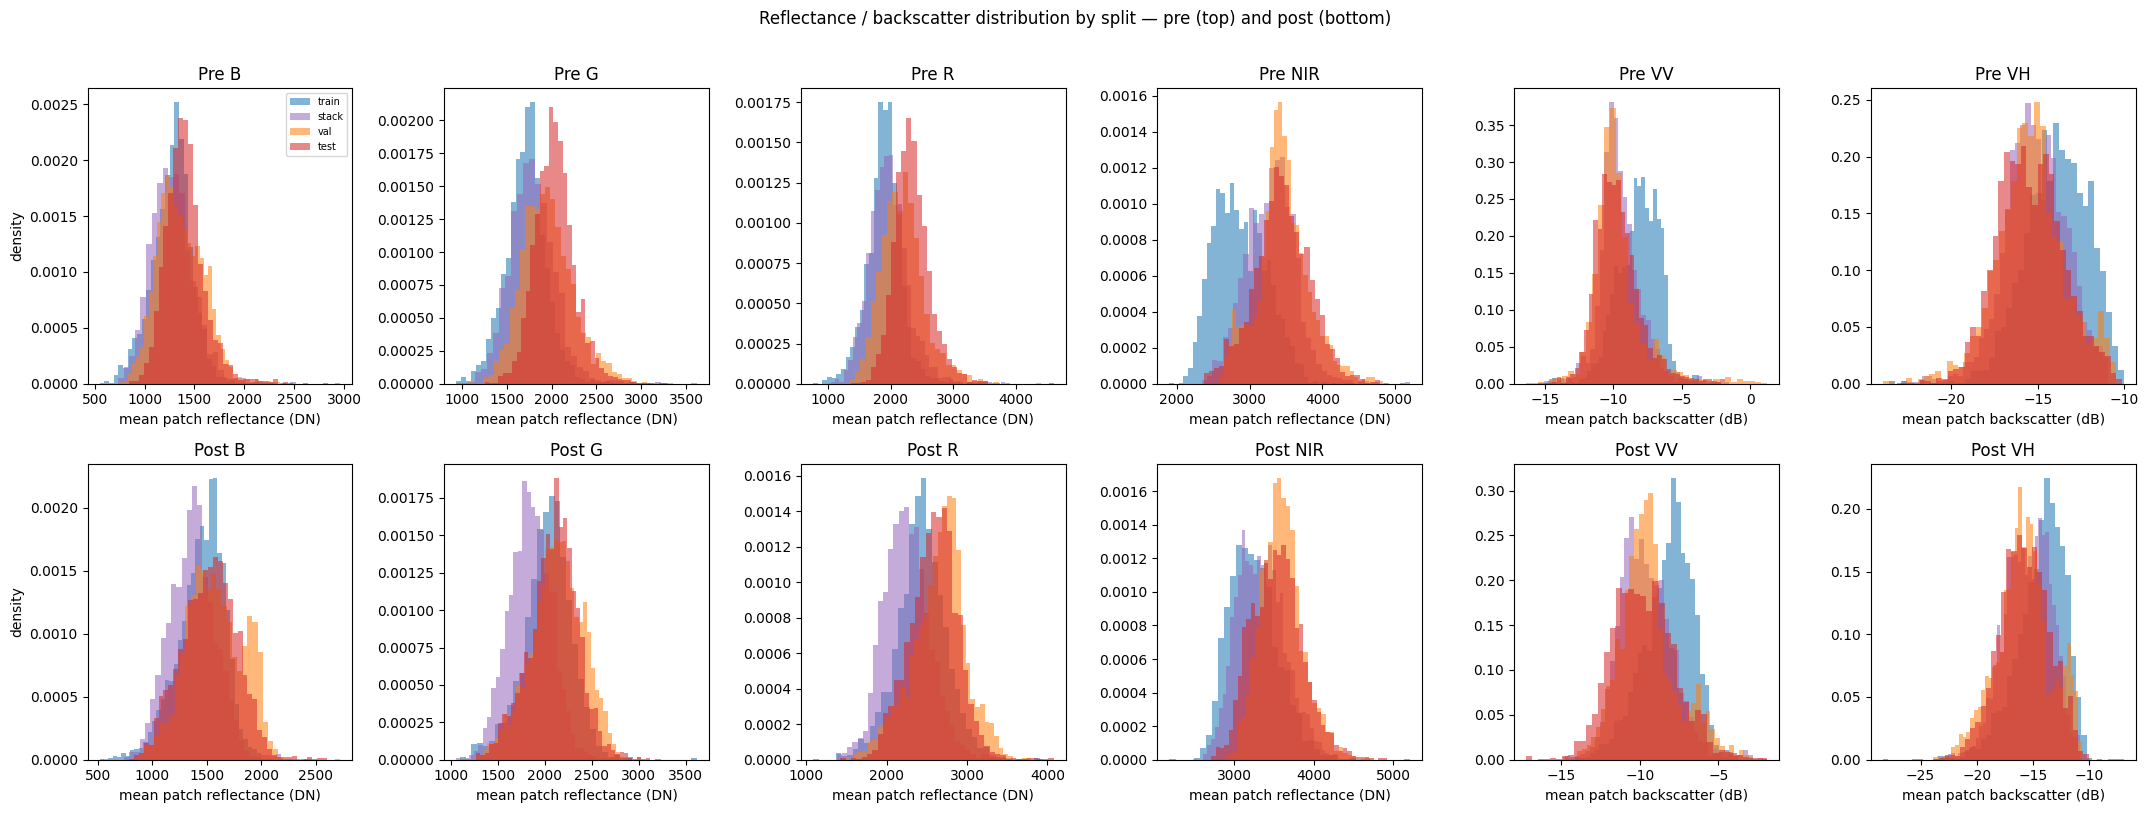

In [22]:
fig, axes = plt.subplots(2, len(ALL_CH_NAMES), figsize=(3.6*len(ALL_CH_NAMES), 8), sharey=False)
for j, band in enumerate(ALL_CH_NAMES):
    for period, row in [('pre', 0), ('post', 1)]:
        ax = axes[row, j]
        ch = ALL_PRE_IDX[j] if period == 'pre' else ALL_POST_IDX[j]
        for role, color in SPLIT_COLORS.items():
            idx = splits[role]
            samp_s = rng.choice(idx, min(3000, len(idx)), replace=False)
            vals = X[samp_s, ch].mean(axis=(1, 2))
            ax.hist(vals, bins=40, density=True, alpha=.55, color=color, label=role)
        ax.set_title(f'{"Pre" if period=="pre" else "Post"} {band}')
        ax.set_xlabel('mean patch reflectance (DN)' if band in BANDS else 'mean patch backscatter (dB)')
        if j == 0: ax.set_ylabel('density')
        if j == 0 and row == 0: ax.legend(fontsize=7)
plt.suptitle('Reflectance / backscatter distribution by split — pre (top) and post (bottom)', y=1.01)
plt.tight_layout()
plt.show()

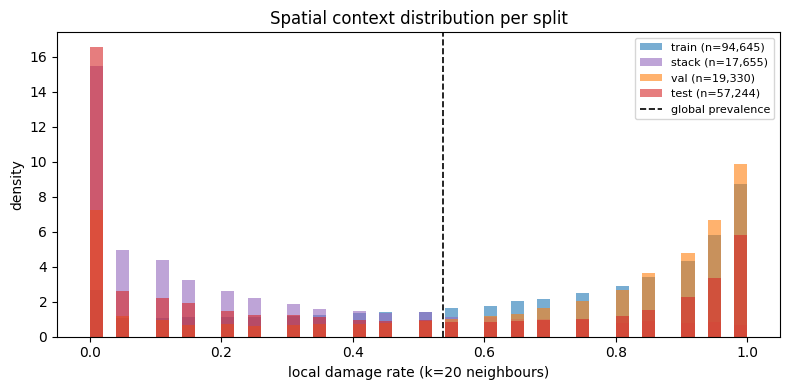

Role        prev%   mean local rate   fraction with local>0.8
train        66.4             0.670                     0.445
stack        24.0             0.246                     0.065
val          64.4             0.652                     0.498
test         38.5             0.391                     0.258


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
for role, color in SPLIT_COLORS.items():
    idx = splits[role]
    ax.hist(local_rate[idx], bins=50, density=True, alpha=.6, color=color, label=f'{role} (n={len(idx):,})')
ax.axvline(y_binary.mean(), color='k', ls='--', lw=1.2, label='global prevalence')
ax.set_xlabel(f'local damage rate (k={K} neighbours)')
ax.set_ylabel('density')
ax.set_title('Spatial context distribution per split')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'{"Role":8s}  {"prev%":>7s}  {"mean local rate":>16s}  {"fraction with local>0.8":>24s}')
for role in roles:
    idx = splits[role]
    print(f'{role:8s}  {100*y_binary[idx].mean():7.1f}  '
          f'{local_rate[idx].mean():16.3f}  '
          f'{(local_rate[idx]>0.8).mean():24.3f}')

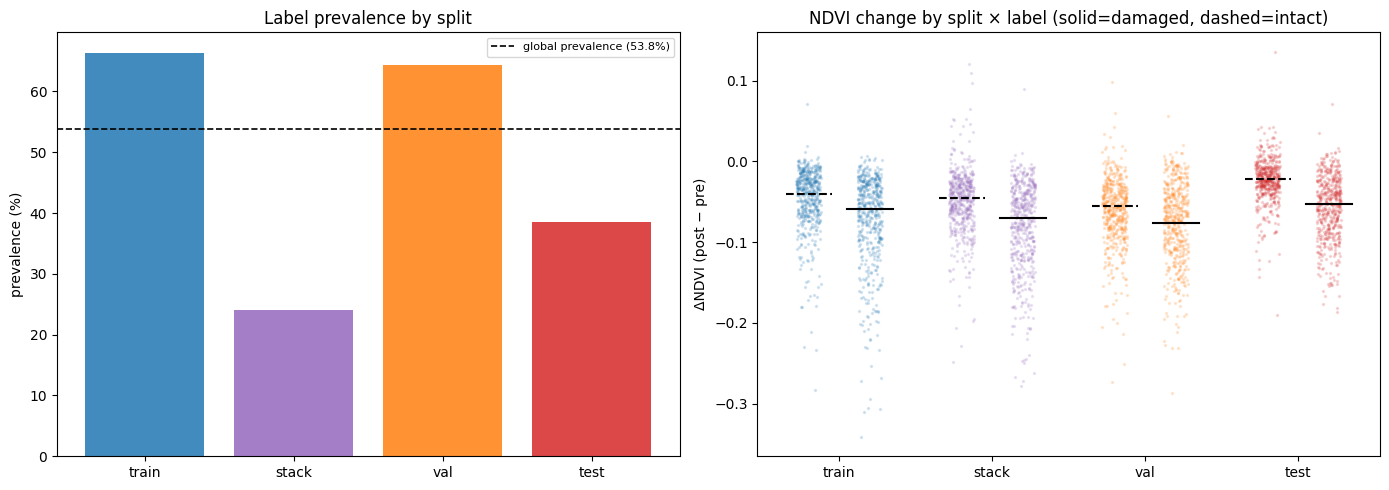

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

global_prev = y_binary.mean()
split_prev  = {r: y_binary[splits[r]].mean() for r in roles}
axes[0].bar(range(len(roles)), [split_prev[r]*100 for r in roles],
            color=[SPLIT_COLORS[r] for r in roles], alpha=.85)
axes[0].axhline(global_prev*100, color='k', ls='--', lw=1.2, label=f'global prevalence ({100*global_prev:.1f}%)')
axes[0].set_xticks(range(len(roles))); axes[0].set_xticklabels(roles)
axes[0].set_ylabel('prevalence (%)'); axes[0].set_title('Label prevalence by split')
axes[0].legend(fontsize=8)

pre_ndvi_fp  = np.where(X[:,3]+X[:,2]>0, (X[:,3]-X[:,2])/(X[:,3]+X[:,2]+1e-6), 0)
post_ndvi_fp = np.where(X[:,7]+X[:,6]>0, (X[:,7]-X[:,6])/(X[:,7]+X[:,6]+1e-6), 0)
ndvi_d = (post_ndvi_fp - pre_ndvi_fp).mean(axis=(1,2))

for j, role in enumerate(roles):
    idx = splits[role]
    for cls, ls, lbl in [(0,'--','intact'),(1,'-','damaged')]:
        vals = ndvi_d[idx[y_binary[idx]==cls]]
        axes[1].plot([], [], color=SPLIT_COLORS[role], ls=ls, label=f'{role} {lbl}' if j<2 else '_')
        xpos = j + (0.2 if cls else -0.2)
        axes[1].scatter(np.full(min(500,len(vals)), xpos) + rng.uniform(-0.08,0.08,min(500,len(vals))),
                        rng.choice(vals, min(500,len(vals)), replace=False),
                        alpha=.15, s=2, color=SPLIT_COLORS[role])
        axes[1].plot([xpos-0.15, xpos+0.15], [np.median(vals)]*2, color='black', lw=1.5, ls=ls)

axes[1].set_xticks(range(len(roles))); axes[1].set_xticklabels(roles)
axes[1].set_ylabel('ΔNDVI (post − pre)')
axes[1].set_title('NDVI change by split × label (solid=damaged, dashed=intact)')

plt.tight_layout()
plt.show()